In [66]:
#testing the ODEsolving etc.

In [67]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [68]:
all_df = pd.read_csv('GSE124821_data.csv')
all_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.020644,0.007343,0.003824,0.005128,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
1,SRX5100686,0.030451,0.010853,0.000000,0.003228,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.030096,0.010989,0.000349,0.004048,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.030466,0.010471,0.000333,0.004030,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.031649,0.008606,0.000000,0.003357,no_treatment,day7,day7,GSM3554695,KPB25L
...,...,...,...,...,...,...,...,...,...,...
187,SRX5100807,0.032076,0.012687,0.000000,0.004420,antiPD1; antiCTLA4;,end,end,GSM3554932,T11
188,SRX5100814,0.027448,0.011238,0.000000,0.004636,antiPD1; antiCTLA4;,end,end,GSM3554933,T11
189,SRX5100813,0.021779,0.009103,0.000000,0.003387,no_treatment,end,end,GSM3554934,T11
190,SRX5100812,0.029557,0.013101,0.000407,0.005049,no_treatment,end,end,GSM3554935,T11


In [94]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')
all_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
1,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,GSM3554695,KPB25L
...,...,...,...,...,...,...,...,...,...,...
187,SRX5100807,0.003208,0.001269,0.000000,0.000442,antiPD1; antiCTLA4;,end,end,GSM3554932,T11
188,SRX5100814,0.002745,0.001124,0.000000,0.000464,antiPD1; antiCTLA4;,end,end,GSM3554933,T11
189,SRX5100813,0.002178,0.000910,0.000000,0.000339,no_treatment,end,end,GSM3554934,T11
190,SRX5100812,0.002956,0.001310,0.000041,0.000505,no_treatment,end,end,GSM3554935,T11


In [ ]:
all_df[(all_df['Condition'].isin(['day3', 'day7', 'end'])) & (all_df['Mouse_treatment']=='no_treatment') & (all_df['Cell_Line']=='KPB25L')]

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
1,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,GSM3554695,KPB25L
8,SRX5100597,0.002915,0.000706,0.000000,0.000280,no_treatment,end,end,GSM3554699,KPB25L
9,SRX5100596,0.003232,0.001002,0.000000,0.000360,no_treatment,day3,day3,GSM3554700,KPB25L
10,SRX5100599,0.002547,0.000642,0.000000,0.000277,no_treatment,end,end,GSM3554701,KPB25L
11,SRX5100598,0.002572,0.000723,0.000000,0.000329,no_treatment,day3,day3,GSM3554702,KPB25L
12,SRX5100618,0.002565,0.000501,0.000000,0.000285,no_treatment,day3,day3,GSM3554703,KPB25L
13,SRX5100617,0.002757,0.000712,0.000000,0.000344,no_treatment,day3,day3,GSM3554704,KPB25L


In [96]:
# showing only UV conditions 
all_df[(all_df['Condition'].isin(['UV_day3', 'UV_day7', 'UV_end'])) & (all_df['Mouse_treatment']=='no_treatment') & (all_df['Cell_Line']=='KPB25L')]

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
32,SRX5100863,0.002851,0.000621,0.000019,0.000439,no_treatment,UV_day3,day3,GSM3554724,KPB25L
33,SRX5100861,0.004423,0.000869,0.000165,0.000540,no_treatment,UV_day3,day3,GSM3554725,KPB25L
34,SRX5100822,0.003585,0.001136,0.000706,0.000580,no_treatment,UV_day3,day3,GSM3554726,KPB25L
36,SRX5100820,0.002572,0.000602,0.000220,0.000284,no_treatment,UV_day3,day3,GSM3554728,KPB25L
45,SRX5100713,0.003293,0.000708,0.000000,0.000487,no_treatment,UV_day7,day7,GSM3554737,KPB25L
46,SRX5100716,0.003005,0.000597,0.000178,0.000265,no_treatment,UV_day7,day7,GSM3554738,KPB25L
48,SRX5100708,0.004482,0.001395,0.000533,0.000871,no_treatment,UV_day7,day7,GSM3554740,KPB25L
49,SRX5100707,0.003791,0.001037,0.000074,0.000702,no_treatment,UV_day7,day7,GSM3554741,KPB25L
53,SRX5100605,0.002386,0.000484,0.000023,0.000222,no_treatment,UV_end,end,GSM3554745,KPB25L
54,SRX5100604,0.004289,0.001399,0.000000,0.000446,no_treatment,UV_end,end,GSM3554746,KPB25L


We are trying to fit Immune Checkpoint treated mice but no UV and no Apobec - so creating that dataset right now. 

In [97]:
# so this is me stratifying by cell line KPB25L but I dont think ilina did that so im going to try without it as well 
ICI_df = all_df[(all_df['Mouse_treatment']!='no_treatment') & (all_df['Cell_Line']=='KPB25L')]
# ICI_df = all_df[(all_df['Mouse_treatment']!='no_treatment')] # SO ILINA DID NOT STRATIFY BY CELL LINE 


quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]
ICI_df



,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
5,SRX5100690,0.002253,0.000725,0.000024,0.000245,antiPD1; antiCTLA4;,day7,day7,GSM3554696,KPB25L
6,SRX5100691,0.003449,0.000867,0.000003,0.000401,antiPD1; antiCTLA4;,day7,day7,GSM3554697,KPB25L
7,SRX5100680,0.004349,0.000949,0.000017,0.000510,antiPD1; antiCTLA4;,day7,day7,GSM3554698,KPB25L
15,SRX5100588,0.002501,0.000555,0.000000,0.000298,antiPD1; antiCTLA4;,day3,day3,GSM3554706,KPB25L
16,SRX5100589,0.005952,0.001135,0.000178,0.000735,antiPD1; antiCTLA4;,day3,day3,GSM3554707,KPB25L
17,SRX5100594,0.003723,0.000832,0.000000,0.000325,antiPD1; antiCTLA4;,day3,day3,GSM3554708,KPB25L
18,SRX5100609,0.004967,0.002358,0.000100,0.000719,antiPD1; antiCTLA4;,day3,day3,GSM3554709,KPB25L
19,SRX5100595,0.005011,0.001828,0.000127,0.000869,antiPD1; antiCTLA4;,day3,day3,GSM3554710,KPB25L
24,SRX5100855,0.003358,0.000808,0.000000,0.000400,antiPD1; antiCTLA4;,end,end,GSM3554715,KPB25L


In [98]:
Ds = []
NKs = []
T8s = []
Tregs = []
scatter_Ds = []
scatter_NKs = []
scatter_Tregs = []
scatter_T8s = []
scatter_times = []


for day in ["day3","day7","end"]:
    day_df = ICI_df[ICI_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    
    print(averages)
    stds = day_df.filter(items=quanTIseq_cols).std()
    
    # print(averages+stds)
    # print(averages-stds)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])
    total = sum(averages)
    print(total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_Ds.append(i)
                scatter_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_T8s.append(i)

print(scatter_Ds)


Number of replicates 5
Dendritic_quanTIseq    0.004431
NK_quanTIseq           0.001341
T.CD8_quanTIseq        0.000081
Tregs_quanTIseq        0.000589
dtype: float64
<class 'pandas.Series'>
0.006442371992000001

Number of replicates 4
Dendritic_quanTIseq    0.003029
NK_quanTIseq           0.000819
T.CD8_quanTIseq        0.000107
Tregs_quanTIseq        0.000417
dtype: float64
<class 'pandas.Series'>
0.0043713391300000005

Number of replicates 3
Dendritic_quanTIseq    0.002631
NK_quanTIseq           0.000629
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.000305
dtype: float64
<class 'pandas.Series'>
0.0035651918266666667
[0.0025009326, 0.0059515362, 0.003723276, 0.0049667706, 0.0050113746, 0.0020644104, 0.0022529988, 0.003449043, 0.0043494576]


Creating the UV light affected dataset as well. 

In [99]:
# -------

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

UV_Ds = []
UV_NKs = []
UV_T8s = []
UV_Tregs = []
scatter_UV_Ds = []
scatter_UV_NKs = []
scatter_UV_Tregs = []
scatter_UV_T8s = []
scatter_UV_times = []

for day in ["UV_day3","UV_day7","UV_end"]:
    day_df = ICI_df[ICI_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)

    stds = day_df.filter(items=quanTIseq_cols).std()

    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    UV_Ds.append(averages["Dendritic_quanTIseq"])
    UV_NKs.append(averages["NK_quanTIseq"])
    UV_T8s.append(averages["T.CD8_quanTIseq"])
    UV_Tregs.append(averages["Tregs_quanTIseq"])
    UV_total = sum(averages)
    print(UV_total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_UV_Ds.append(i)
                scatter_UV_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_UV_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_UV_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_UV_T8s.append(i)

print(scatter_Ds)



Number of replicates 3
Dendritic_quanTIseq    0.002739
NK_quanTIseq           0.000659
T.CD8_quanTIseq        0.000013
Tregs_quanTIseq        0.000319
dtype: float64
<class 'pandas.Series'>
0.0037304873926666668

Number of replicates 6
Dendritic_quanTIseq    0.002793
NK_quanTIseq           0.000841
T.CD8_quanTIseq        0.001130
Tregs_quanTIseq        0.000748
dtype: float64
<class 'pandas.Series'>
0.00551219984

Number of replicates 4
Dendritic_quanTIseq    0.002188
NK_quanTIseq           0.000766
T.CD8_quanTIseq        0.000037
Tregs_quanTIseq        0.000246
dtype: float64
<class 'pandas.Series'>
0.0032370465800000002
[0.0025009326, 0.0059515362, 0.003723276, 0.0049667706, 0.0050113746, 0.0020644104, 0.0022529988, 0.003449043, 0.0043494576]


In [125]:
import math 
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
    
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.0,
          'lambda_DC_comb':8e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':5e-5,
          'd_N':0.1,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.18,
          'lambda_T8_comb':1.08e-3,
          'K_Tr':2.5e-4,
          'K_D':4e-4 
          }
init_conds = {'C_init':0.8,
              'D_init':0.0,
              'N_init':0.0,
              'Tr_init':0.0,
              'T8_init':0.0
              }
          

lambda_C   = params['lambda_C']
C_M        = params['C_M']
eta_8      = params['eta_8']
eta_N      = params['eta_N']
d_C            = params['d_C']
lambda_DC_comb = params['lambda_DC_comb']
K_C        = params['K_C']
d_D        = params['d_D']
sigma_N    = params['sigma_N']
d_N        = params['d_N']
gamma_N    = params['gamma_N']
a_C        = params['a_C']
beta_1     = params['beta_1']
beta_2     = params['beta_2']
d_Tr       = params['d_Tr']
lambda_Tr_comb  = params['lambda_Tr_comb']
d_T8       = params['d_T8']
lambda_T8_comb  = params['lambda_T8_comb']
K_Tr       = params['K_Tr']
K_D        = params['K_D']


C_init     = init_conds['C_init']
D_init     = init_conds['D_init']
N_init     = init_conds['N_init']
Tr_init    = init_conds['Tr_init']
T8_init    = init_conds['T8_init']


objective_function_day3 = {'Ds':Ds[0],
                          'NKs':NKs[0],
                          'Tregs':Tregs[0],
                          'T8s':T8s[0]}
objective_function_day7 = {'Ds':Ds[1],
                          'NKs':NKs[1],
                          'Tregs':Tregs[1],
                          'T8s':T8s[1]}

print (Ds)



def mean_square_error_rel(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

[np.float64(0.004430778000000001), np.float64(0.0030289774500000003), np.float64(0.0026314756)]


In [126]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
# this is a parameter sweep dictionary 
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Treg': [2.0e-5,2.5e-5,3.0e-5]}


In [127]:
import itertools

def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )
changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
for combo in itertools.product(*values):
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = init_conds['C_init']
    D_init     = init_conds['D_init']
    N_init     = init_conds['N_init']
    Tr_init    = init_conds['Tr_init']
    T8_init    = init_conds['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-8,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            best_params = params.copy()
            print(mean_square_error_rel(sol.y)) 
print(f'The minimum error is {minimum_distance}')
print({k:best_params[k] for k in params_to_change.keys()})

10.024422800119634
4.793485656704883
3.3517338400190617
3.3517150627121066
3.3516959328341187
3.3516577664243683
3.3492792104339983
3.3486954861794627
3.347927565010716
2.431445082629887
2.4314203375896684
2.431395128072569
2.4313448325378495
2.4282178213483094
2.4274580053303745
2.426521955416071
2.1631955607974356
2.16316803429225
2.1631399910683355
2.1630840419143804
2.159606666005987
2.1587632461995514
2.157738203762258
2.041074683335876
2.0410456303786217
2.0410160320035033
2.040956980028274
2.0372868646023816
2.0363971201438913
2.0353202885221044
1.6534845235473425
1.6534488935074876
1.6534125938904756
1.653340170125412
1.6488312486705576
1.647733674465808
1.646377507761475
1.6234211854437797
1.6233847884694736
1.6233477071794427
1.6232737228462168
1.6186624067718653
1.6175359556863287
1.6161147268210863
1.611747132426075
1.61060577992571
1.609133686912893
1.3632425725341928
1.3631955652839722
1.3631476512424436
1.3630519835253183
1.35681100626496
1.3551172812504737
1.35193749864

So here, we plot the ODE with the parameters that we have just fitted and also add the data to the graph to see if its a good fit.

In [128]:
tspan = (0.0,14.0,)
C_init     = init_conds['C_init']
D_init     = init_conds['D_init']
N_init     = init_conds['N_init']
Tr_init    = init_conds['Tr_init']
T8_init    = init_conds['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,)) 

t = sol.t
y = sol.y

print (len(scatter_Ds)) 
print (len(scatter_times))
print (best_params)

9
9
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.0, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004, 'd_N': 0.11, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.25, 'lambda_T8_comb': 0.0001, 'K_Tr': 0.00025, 'K_D': 0.0004, 'K_Treg': 2e-05}


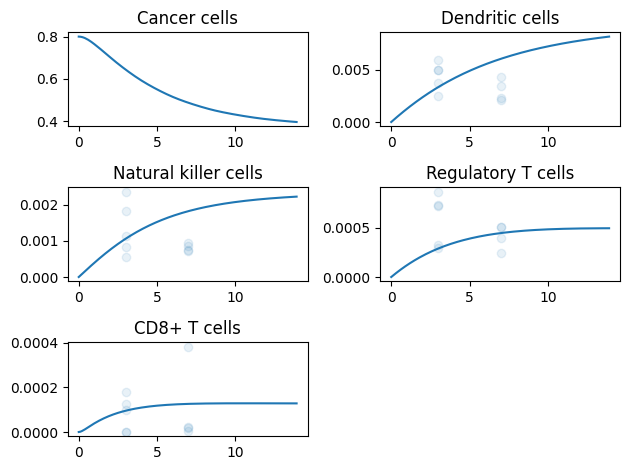

In [129]:


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1)

NK_cells = ax[1,0]
NK_cells.plot(t,y[2])

NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1)
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1)
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1)
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

# fit to UV and Apobec for tomorroww!!!!!!! 

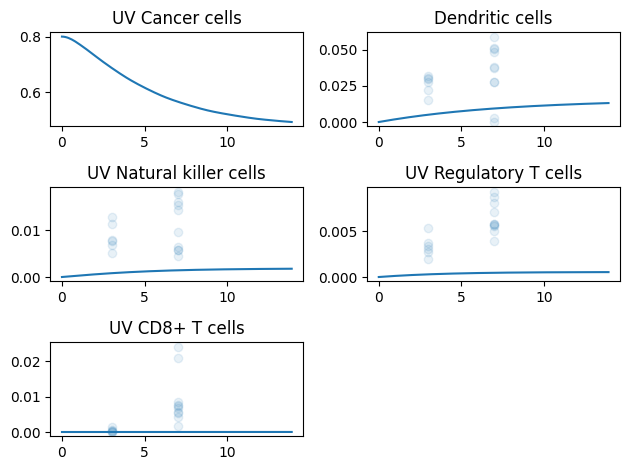

In [82]:
t = sol.t
y = sol.y
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('UV Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
D_cells.scatter(scatter_UV_times,scatter_UV_Ds,alpha=0.1)

NK_cells = ax[1,0]
NK_cells.plot(t,y[2])

NK_cells.set_title('UV Natural killer cells')
NK_cells.scatter(scatter_UV_times,scatter_UV_NKs,alpha=0.1)
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('UV Regulatory T cells')
Treg.scatter(scatter_UV_times,scatter_UV_Tregs,alpha=0.1)
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('UV CD8+ T cells')
T8.scatter(scatter_UV_times,scatter_UV_T8s,alpha=0.1)
extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()